In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score


## 1. Leitura da base


In [89]:
# No Google Colab, mantenha o arquivo restaurante.csv nesta pasta
base = pd.read_csv('/content/sample_data/restaurante.csv', sep=';')

base.head()


,Alternativo,Bar,SexSab,fome,Cliente,Preco,Chuva,Res,Tipo,Tempo,Conclusao
0,Sim,Nao,Nao,Sim,Alguns,RRR,Nao,Sim,Frances,0-10,Sim
1,Sim,Nao,Nao,Sim,Cheio,R,Nao,Nao,Tailandes,30-60,Nao
2,Nao,Sim,Nao,Nao,Alguns,R,Nao,Nao,Hamburger,0-10,Sim
3,Sim,Nao,Sim,Sim,Cheio,R,Sim,Nao,Tailandes,10-30,Sim
4,Sim,Nao,Sim,Nao,Cheio,RRR,Nao,Sim,Frances,>60,Nao


## 2. Contando a quantidade de instâncias de cada **classe**

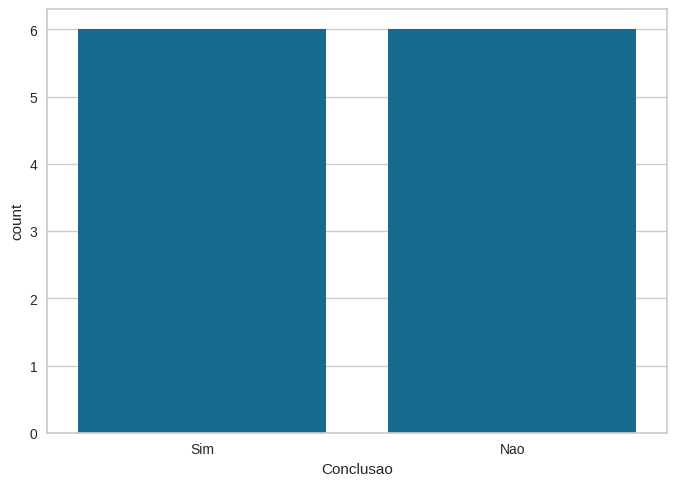

In [90]:
Classificação = base.columns[-1]
np.unique(base[Classificação], return_counts=True)
sns.countplot(x = base[Classificação]);

## 3. Separação automática dos atributos e da classe


In [91]:
# Supondo que a última coluna seja o target
X= base.iloc[:, :-1]
Y = base.iloc[:, -1]

## 4. Codificação dos atributos


In [92]:
# 3.1 Colunas binárias Sim/Nao: identificação e codificação automáticas
mapa_binario = {'Nao': 0, 'Sim': 1}

colunas_binarias = [
    coluna for coluna in X.columns
    if set(X[coluna].dropna().unique()).issubset(mapa_binario.keys())
]

X[colunas_binarias] = X[colunas_binarias].apply(
    lambda coluna: coluna.map(mapa_binario)
)

# 3.2 Cliente: ordem definida explicitamente
# A base original usa "Alguns"; "Algum" também é aceito.
mapa_cliente = {
    'Nenhum': 0,
    'Algum': 1,
    'Alguns': 1,
    'Cheio': 2
}
X['Cliente'] = X['Cliente'].map(mapa_cliente)

# 3.3 Variáveis ordinais
X['Preco'] = X['Preco'].map({
    'R': 0,
    'RR': 1,
    'RRR': 2
})

X['Tempo'] = X['Tempo'].map({
    '0-10': 0,
    '10-30': 1,
    '30-60': 2,
    '>60': 3
})

# 3.4 Variável nominal Tipo: One-Hot Encoding
X = pd.get_dummies(X, columns=['Tipo'], dtype=int)

# Verificação
X


/tmp/ipykernel_1074/4076392214.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[colunas_binarias] = X[colunas_binarias].apply(
/tmp/ipykernel_1074/4076392214.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cliente'] = X['Cliente'].map(mapa_cliente)
/tmp/ipykernel_1074/4076392214.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

,Alternativo,Bar,SexSab,fome,Cliente,Preco,Chuva,Res,Tempo,Tipo_Frances,Tipo_Hamburger,Tipo_Italiano,Tipo_Tailandes
0,1,0,0,1,1,2,0,1,0,1,0,0,0
1,1,0,0,1,2,0,0,0,2,0,0,0,1
2,0,1,0,0,1,0,0,0,0,0,1,0,0
3,1,0,1,1,2,0,1,0,1,0,0,0,1
4,1,0,1,0,2,2,0,1,3,1,0,0,0
5,0,1,0,1,1,1,1,1,0,0,0,1,0
6,0,1,0,0,0,0,1,0,0,0,1,0,0
7,0,0,0,1,1,1,1,1,0,0,0,0,1
8,0,1,1,0,2,0,1,0,3,0,1,0,0
9,1,1,1,1,2,2,0,1,1,0,0,1,0


## 5. Divisão entre treino e teste


In [93]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Treino:', X_treino.shape)
print('Teste:', X_teste.shape)


Treino: (9, 13)
Teste: (3, 13)


## 6. Treinamento da Árvore de Decisão


In [94]:
arvore = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

arvore.fit(X_treino, y_treino)

previsoes = arvore.predict(X_teste)
acuracia = accuracy_score(y_teste, previsoes)

print(f'Acurácia: {acuracia:.2%}')


Acurácia: 33.33%


## 7. Mostrando a matriz de confusão

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.3333333333333333

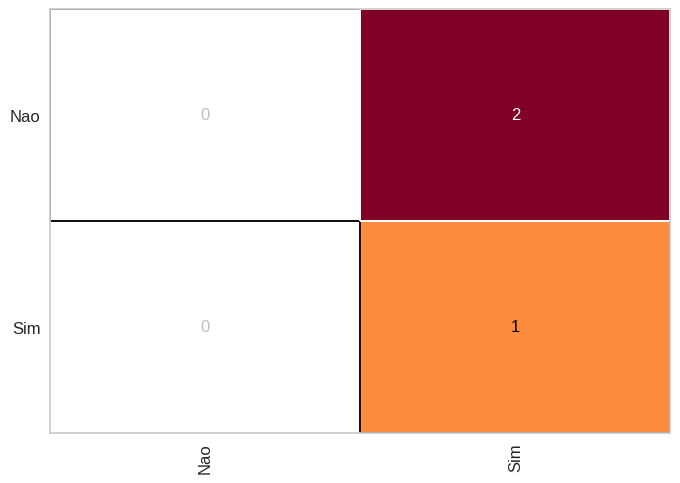

In [95]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
#confusion_matrix(y_teste, previsoes)

cm = ConfusionMatrix(arvore)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [96]:
X_teste

,Alternativo,Bar,SexSab,fome,Cliente,Preco,Chuva,Res,Tempo,Tipo_Frances,Tipo_Hamburger,Tipo_Italiano,Tipo_Tailandes
7,0,0,0,1,1,1,1,1,0,0,0,0,1
8,0,1,1,0,2,0,1,0,3,0,1,0,0
9,1,1,1,1,2,2,0,1,1,0,0,1,0


In [97]:
y_teste

,Conclusao
7,Sim
8,Nao
9,Nao


In [98]:
previsoes

array(['Sim', 'Sim', 'Sim'], dtype=object)

## 6. Visualização da árvore


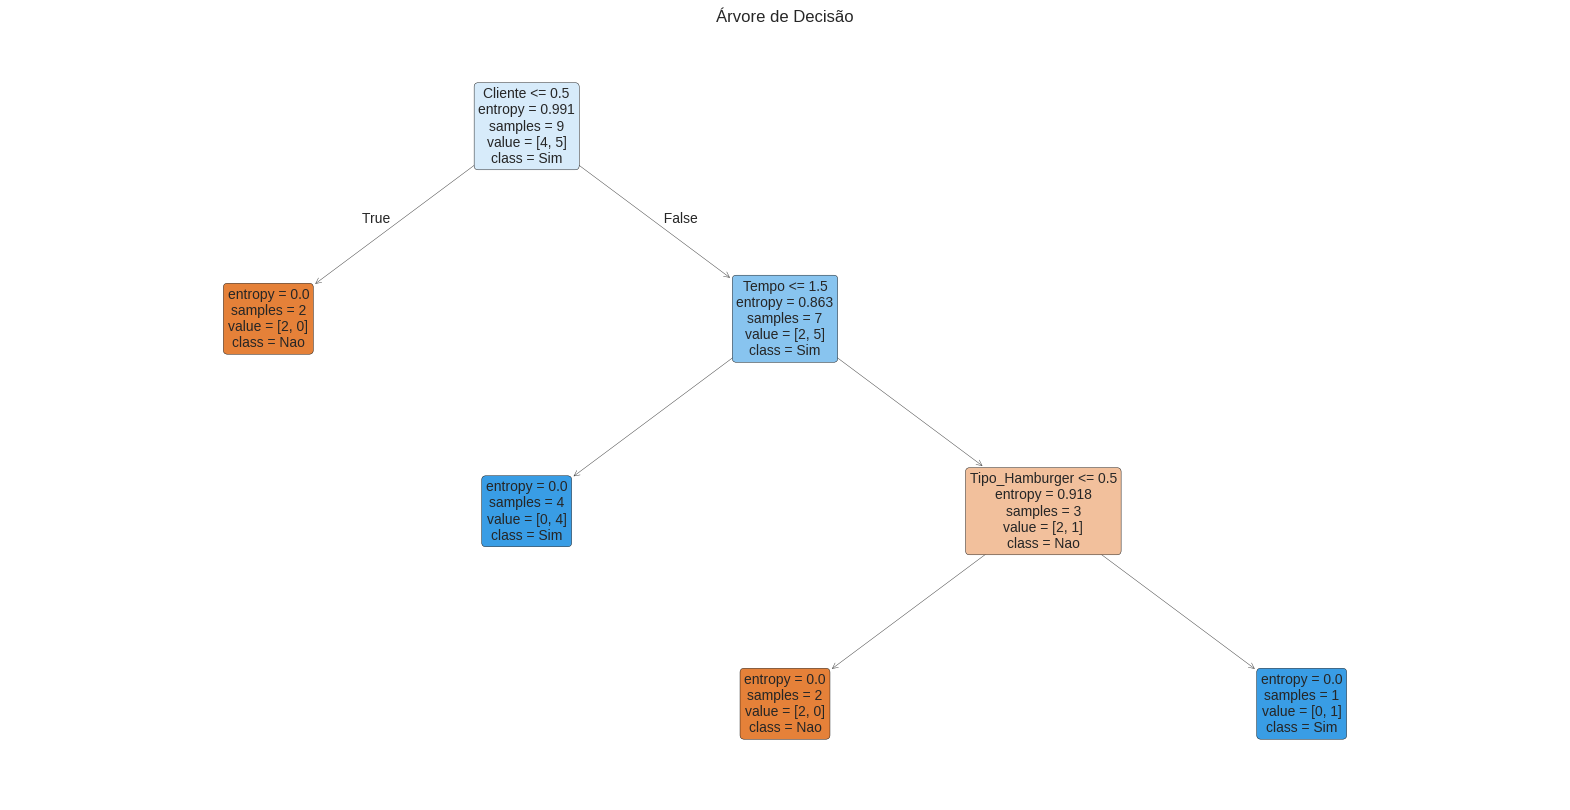

In [99]:
plt.figure(figsize=(20, 10))

plot_tree(
    arvore,
    feature_names=X.columns,
    class_names=[str(classe) for classe in arvore.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Árvore de Decisão')
plt.show()


## 8. Mostrando a qualidade da árvore

In [100]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

         Nao       0.00      0.00      0.00         2
         Sim       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
